In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

In [3]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Estraiamo tutti i concetti unici per mapparli ad un ID numerico
    concepts = set()
    for item in data:
        concepts.add(item[0]) # concept_i
        concepts.add(item[1]) # concept_j
        
    concept2id = {c: idx for idx, c in enumerate(list(concepts))}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [4]:
dataset, concept2id, id2concept = load_data(JSON_PATH)

In [ ]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [ ]:
train_box(model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4399
Epoca [10/100] | Loss: 0.1747
Epoca [20/100] | Loss: 0.0455
Epoca [30/100] | Loss: 0.0171
Epoca [40/100] | Loss: 0.0087
Epoca [50/100] | Loss: 0.0054
Epoca [60/100] | Loss: 0.0041
Epoca [70/100] | Loss: 0.0033
Epoca [80/100] | Loss: 0.0029
Epoca [90/100] | Loss: 0.0026
Epoca [100/100] | Loss: 0.0025

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0031
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


In [7]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

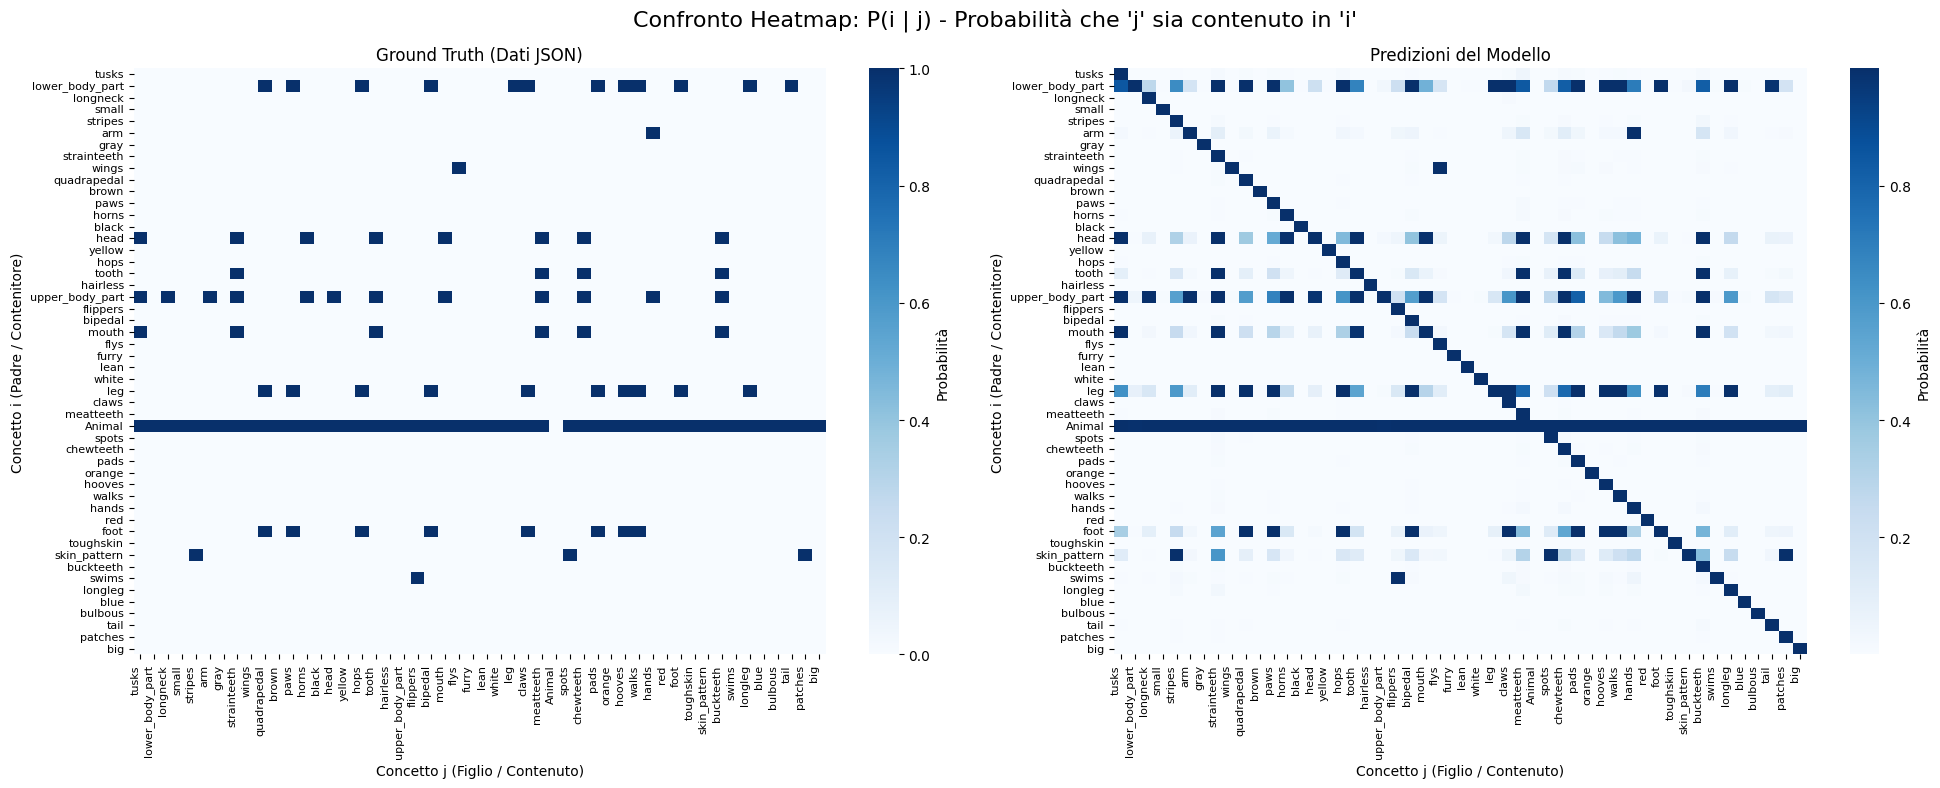

In [8]:
visualize_heatmap_compare(model, dataset, concept2id, id2concept)

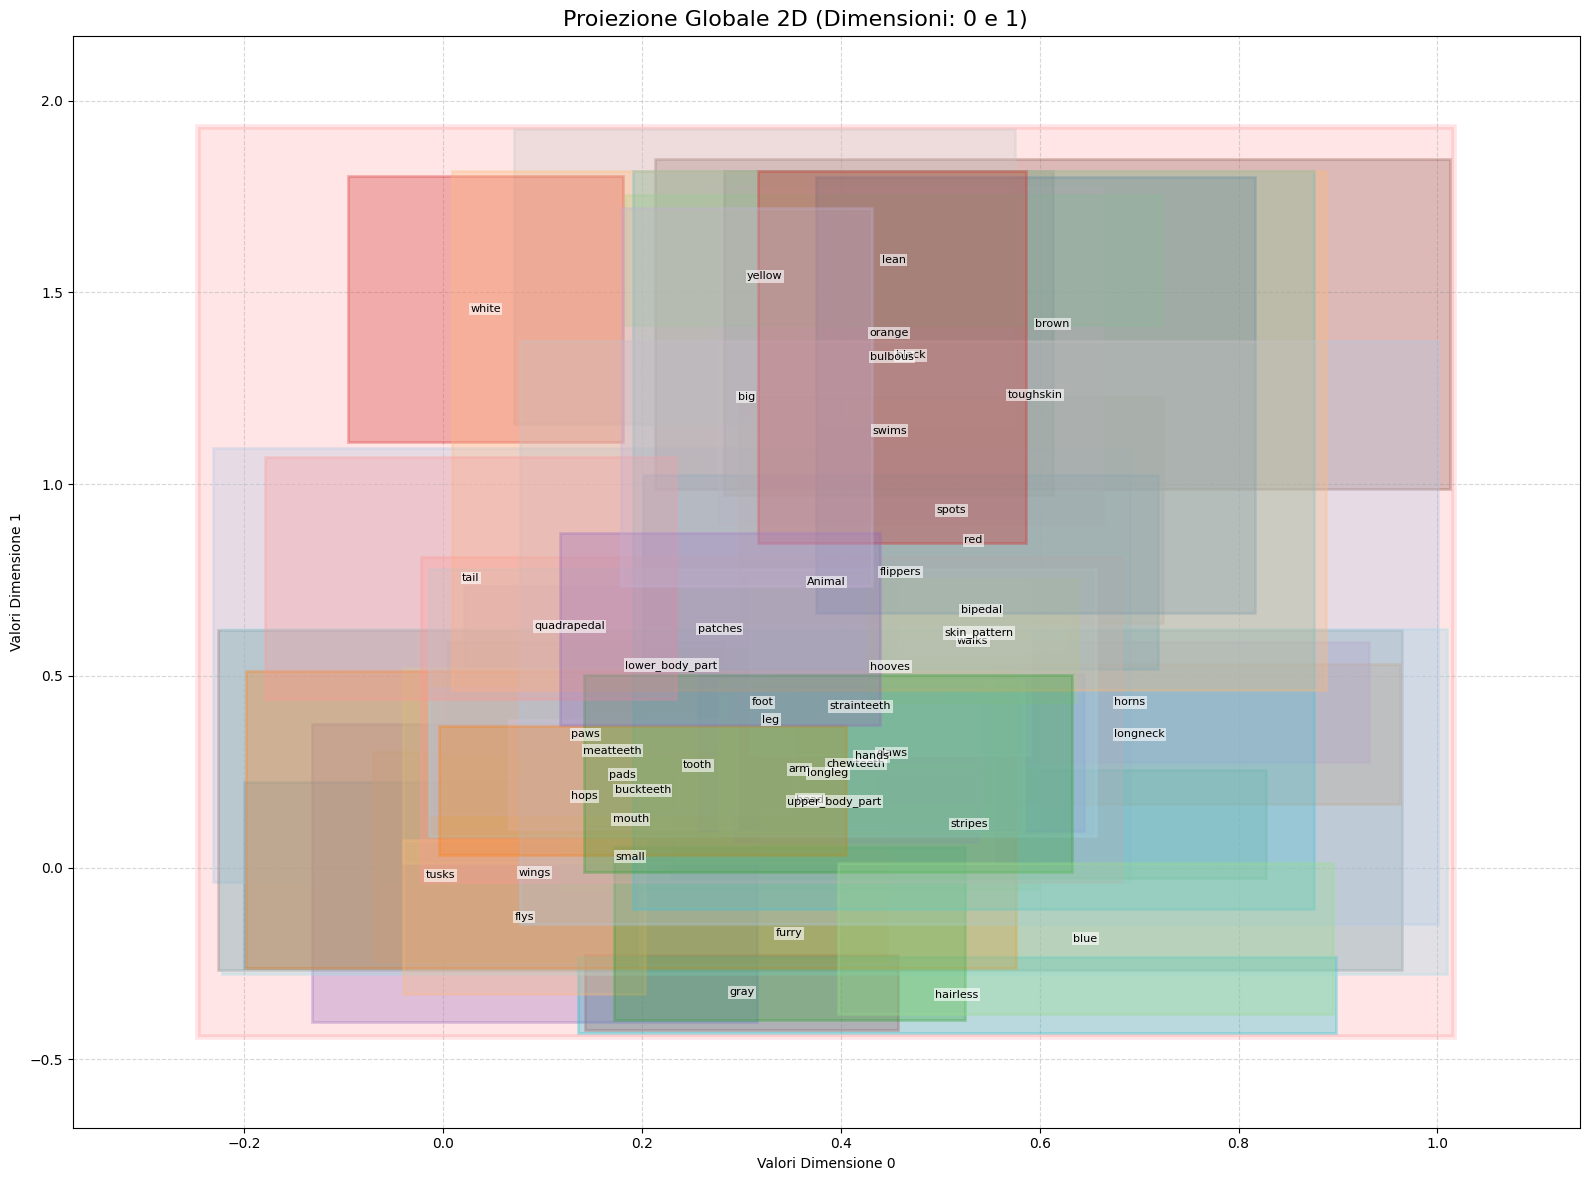

In [9]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(model, id2concept, dim_x=0, dim_y=1)

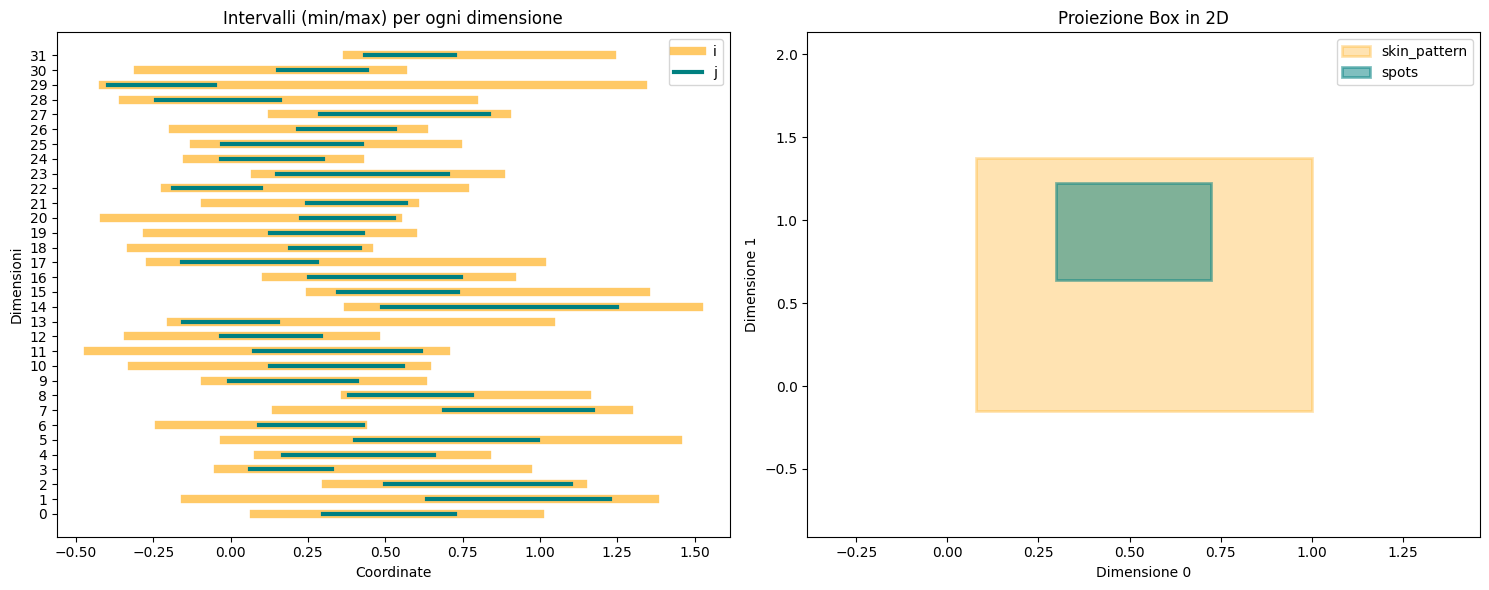

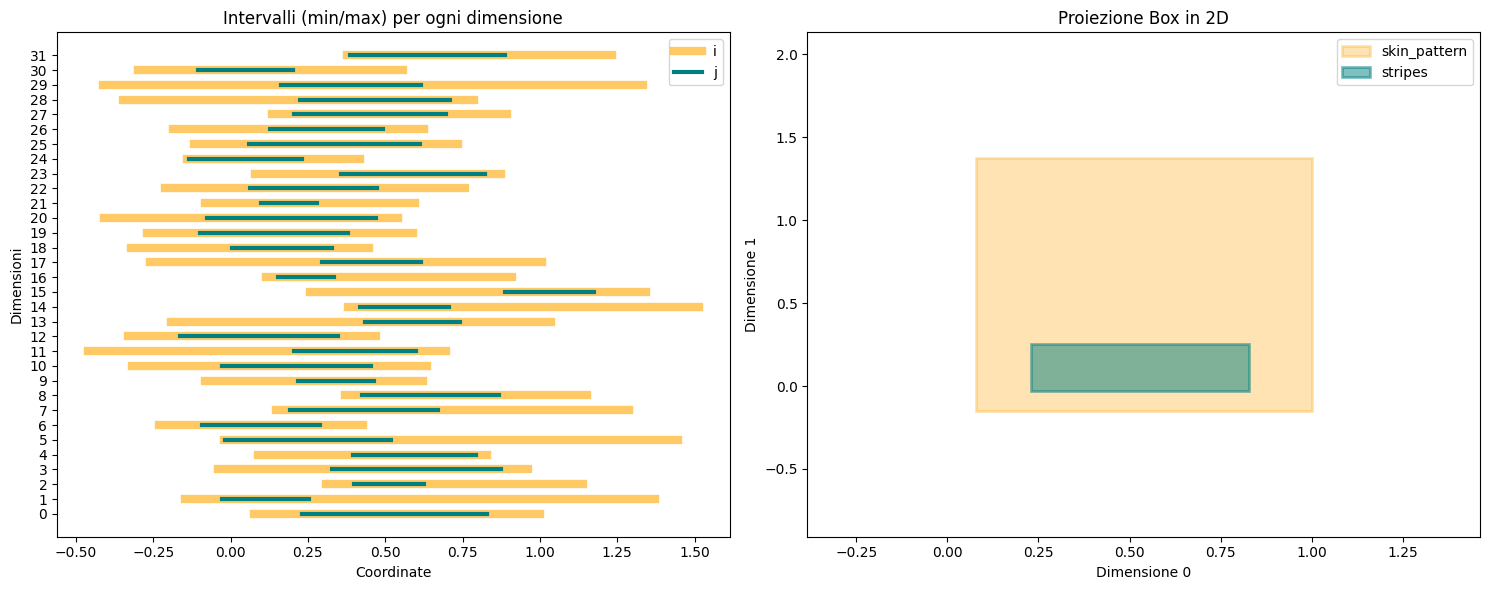

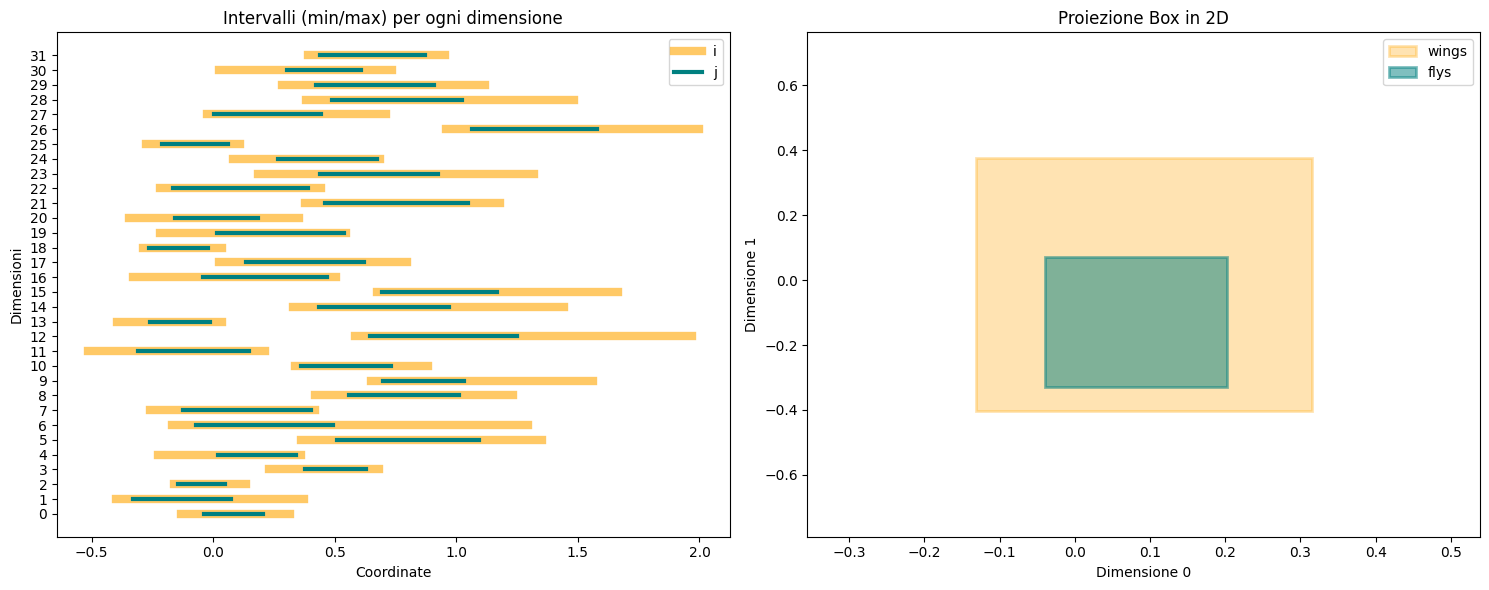

In [10]:
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "spots")
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "stripes")
visualize_concept_hierarchy(model, id2concept, concept2id, "wings", "flys")

In [11]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(model, id2concept)

In [ ]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0171, 1.9310, 1.2206, 0.9974, 1.5273, 1.4716, 2.2166, 1.3190, 1.2908,
         1.8078, 1.3447, 1.1283, 2.0128, 1.0493, 1.5522, 1.8674, 1.2400, 1.0748,
         1.0619, 0.9477, 1.4375, 1.2514, 1.2734, 1.4361, 1.0525, 1.1065, 2.0780,
         0.9936, 1.7536, 1.3652, 0.8722, 1.2802]])
Coordinate z (min) per 'wings': tensor([[-0.1319, -0.4021, -0.1609,  0.2272, -0.2288,  0.3602, -0.1691, -0.2611,
          0.4167,  0.6490,  0.3374, -0.5170,  0.5821, -0.3971,  0.3261,  0.6744,
         -0.3322,  0.0226, -0.2876, -0.2181, -0.3458,  0.3788, -0.2172,  0.1841,
          0.0822, -0.2775,  0.9559, -0.0266,  0.3801,  0.2847,  0.0220,  0.3912]])


In [13]:
import torch
torch.save(model.state_dict(), "modello_gerarchia.pth")

In [14]:
model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [15]:
box_dict = get_box_dict(model, id2concept)

In [16]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0171, 1.9310, 1.2206, 0.9974, 1.5273, 1.4716, 2.2166, 1.3190, 1.2908,
         1.8078, 1.3447, 1.1283, 2.0128, 1.0493, 1.5522, 1.8674, 1.2400, 1.0748,
         1.0619, 0.9477, 1.4375, 1.2514, 1.2734, 1.4361, 1.0525, 1.1065, 2.0780,
         0.9936, 1.7536, 1.3652, 0.8722, 1.2802]])
Coordinate z (min) per 'wings': tensor([[-0.1319, -0.4021, -0.1609,  0.2272, -0.2288,  0.3602, -0.1691, -0.2611,
          0.4167,  0.6490,  0.3374, -0.5170,  0.5821, -0.3971,  0.3261,  0.6744,
         -0.3322,  0.0226, -0.2876, -0.2181, -0.3458,  0.3788, -0.2172,  0.1841,
          0.0822, -0.2775,  0.9559, -0.0266,  0.3801,  0.2847,  0.0220,  0.3912]])


In [ ]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np  # numero di classi è dato dal numero di classi uniche nei label di training

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [ ]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier


model = ConceptBottleneckClassifier(box_dim=BOX_DIM, num_classes=NUM_CLASSES)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)